[@LorenaABarba](https://twitter.com/LorenaABarba)

通往 Navier–Stokes 方程的 12 个步骤
======
***

本 Jupyter notebook 延续了 **通往 Navier–Stokes 方程的 12 个步骤** 的讲解，这是 [Lorena Barba 教授](http://lorenabarba.com) 在交互式 CFD 课堂上所讲授的实践模块。在继续学习之前，你应该已经完成了 [第 1 步](../step_1/step_1.ipynb)，并编写了自己的 Python 脚本或 notebook，亲身尝试过改变离散化参数并观察会发生什么。


第 2 步：非线性对流
-----
***

现在我们将使用与第 1 步相同的方法来实现非线性对流。一维对流方程为：

$$\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x} = 0$$

在方程的第二项中，乘子不再是常数因子 $c$，而是解本身 $u$。因此，方程的第二项现在是 *非线性* 的。我们将沿用第 1 步中使用的离散化方式——时间上前向差分、空间上后向差分。离散化后的方程如下。

$$\frac{u_i^{n+1}-u_i^n}{\Delta t} + u_i^n \frac{u_i^n-u_{i-1}^n}{\Delta x} = 0$$

求解唯一的未知项 $u_i^{n+1}$，得到：

$$u_i^{n+1} = u_i^n - u_i^n \frac{\Delta t}{\Delta x} (u_i^n - u_{i-1}^n)$$

与之前一样，Python 代码首先加载必要的库。然后，我们声明一些用于确定空间和时间离散化的变量（你可以尝试改变这些参数，观察会发生什么）。接着，我们通过初始化解的数组来构造初始条件 $u_0$：在 $0.5 \leq x \leq 1$ 区间内令 $u = 2$，而在 $(0,2)$ 的其余位置令 $u = 1$（即一个帽函数）。

In [1]:
import numpy                 # 我们导入 numpy 
from matplotlib import pyplot    # 以及我们的二维绘图库
%matplotlib inline


nx = 41
dx = 2 / (nx - 1)
nt = 20    # nt 是我们希望计算的时间步数
dt = .025  # dt 是每个时间步所跨越的时间长度（delta t）

u = numpy.ones(nx)      # 和之前一样，我们将 u 初始化为所有值均为 1 的数组。
u[int(.5 / dx) : int(1 / dx + 1)] = 2  # 然后根据我们的初始条件，在 0.5 到 1 之间令 u = 2

un = numpy.ones(nx) # 初始化占位数组 un，用来保存时间步推进后的解

下面的代码片段是 *未完成* 的。我们已经从 [第 1 步](../step_1/step_1.ipynb) 复制了执行时间步更新的一行代码。你能否修改这段代码，使其执行非线性对流？

In [ ]:
for n in range(nt):  # 在时间上迭代
    un = u.copy() ## 将 u 中已有的值拷贝到 un
    for i in range(1, nx):  ## 接下来我们遍历 u 数组
    
     ### 这一行是直接从第 1 步原样复制过来的。请根据新方程进行修改。
     ### 然后取消注释，运行该单元格即可计算第 2 步   
      
           ###u[i] = un[i] - c * dt / dx * (un[i] - un[i-1]) 

        
pyplot.plot(numpy.linspace(0, 2, nx), u) ## 绘制结果

在非线性对流方程下，你观察到了帽函数怎样的演化？当你改变数值参数并再次运行时，会发生什么？

## 了解更多

若想仔细了解如何用有限差分方法对流方程进行离散化（包括第 1 步到第 4 步的全部内容），请在 YouTube 上观看 Barba 教授的 **第 4 课视频**。

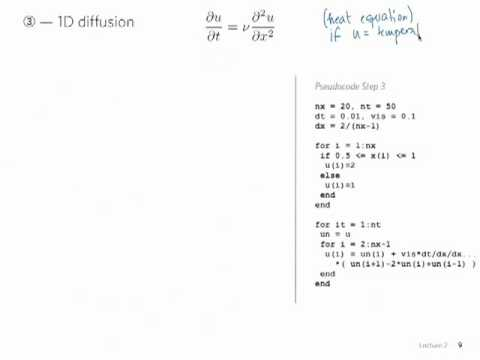

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('y2WaK7_iMRI')

In [3]:
from IPython.core.display import HTML
def css_styling():
    styles = open("../../styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

> （上面的单元格用于为该 notebook 应用样式。）